# Group 4 - World Happiness Report Analysis
**Solavise Women in Data (SWID) Programme | Week 8 Hackathon**

**Theme:** Finance & Economics | **Dataset:** WHR_15_23.csv (1367 rows, 2015–2023)

**Skills demonstrated:** Data Cleaning · NumPy · Pandas · Visualisation · Machine Learning · Storytelling

---
### Our Data Story
- *What makes a country happy — and can we predict it from economic and social data?*

- We analyse happiness trends across 9 years and 165 countries, compare regions, explore relationships between economic indicators and wellbeing, and build a model to predict a country's happiness score.

In [8]:
# Import Libraries
# It loads every tool we need for the entire notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
sns.set_palette('Set2')

In [34]:
# Load the Dataset
import os

df = pd.read_csv('WHR_15_23.csv')

## Exploring the Data

Before cleaning anything, we explore the dataset to understand what we are working with.

This is always the first step. We should never clean data we have not looked at first.

In [11]:
# First 5 rows
df.head()

,country,region,happiness_score,gdp_per_capita,generosity,social_support,freedom_to_make_life_choices,healthy_life_expectancy,year
0,Switzerland,Western Europe,7.587,1.39651,0.29678,1.34951,0.66557,0.94143,2015
1,Iceland,Western Europe,7.561,1.30232,0.43630,1.40223,0.62877,0.94784,2015
2,Denmark,Western Europe,7.527,1.32548,0.34139,1.36058,0.64938,0.87464,2015
3,Norway,Western Europe,7.522,1.45900,0.34699,1.33095,0.66973,0.88521,2015
4,Canada,North America and ANZ,7.427,1.32629,0.45811,1.32261,0.63297,0.90563,2015


In [ ]:
# Last 5 rows
df.tail()

,country,region,happiness_score,gdp_per_capita,generosity,social_support,freedom_to_make_life_choices,healthy_life_expectancy,year
1362,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.183,0.784,0.375,0.105,2023
1363,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.112,0.881,0.363,0.069,2023
1364,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.193,0.540,0.371,0.092,2023
1365,Lebanon,Middle East and North Africa,2.392,1.417,0.061,0.476,0.123,0.398,2023
1366,Afghanistan,South Asia,1.859,0.645,0.093,0.000,0.000,0.087,2023


In [ ]:
# Column types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       1367 non-null   object 
 1   region                        1367 non-null   object 
 2   happiness_score               1367 non-null   float64
 3   gdp_per_capita                1367 non-null   float64
 4   generosity                    1367 non-null   float64
 5   social_support                1367 non-null   float64
 6   freedom_to_make_life_choices  1367 non-null   float64
 7   healthy_life_expectancy       1366 non-null   float64
 8   year                          1367 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 96.2+ KB


In [ ]:
# Statistical summary — min, max, mean, std for every numeric column
df.describe()

,happiness_score,gdp_per_capita,generosity,social_support,freedom_to_make_life_choices,healthy_life_expectancy,year
count,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000
mean,5.441086,1.026178,0.197561,1.052262,0.453759,0.587917,2018.903438
std,1.117909,0.446042,0.112168,0.320034,0.152373,0.240367,2.561006
min,1.859000,0.015300,0.001990,0.058000,0.005890,0.005565,2015.000000
25%,4.599500,0.717171,0.116955,0.841710,0.360615,0.408500,2017.000000
50%,5.440000,1.043000,0.184010,1.083000,0.467610,0.612448,2019.000000
75%,6.256300,1.338473,0.252858,1.299985,0.568685,0.777602,2021.000000
max,7.842000,2.209000,0.838075,1.644000,0.772000,1.141000,2023.000000


In [ ]:
# A random sample of 5 rows — useful for spotting unexpected values
df.sample(5)

,country,region,happiness_score,gdp_per_capita,generosity,social_support,freedom_to_make_life_choices,healthy_life_expectancy,year
261,Honduras,Latin America and Caribbean,4.871,0.69429,0.20440,0.75596,0.26755,0.58383,2016
1316,North Macedonia,Central and Eastern Europe,5.254,1.49800,0.20700,1.17100,0.51500,0.40800,2023
20,United Kingdom,Western Europe,6.867,1.26637,0.51912,1.28548,0.59625,0.90943,2015
1226,Rwanda,Sub-Saharan Africa,3.268,0.78500,0.18700,0.13300,0.62100,0.46200,2022
1349,Mali,Sub-Saharan Africa,4.198,0.76300,0.12100,0.63700,0.44100,0.10600,2023


#Data Cleaning

After exploring, here is what we found:

- 1 missing value - `healthy_life_expectancy` - State of Palestine 2023
> Solution: Fill with column mean

- Zeros as missing - 9 zeros across 5 numeric columns (not valid values)
> Solution: Convert to NaN, then fill with mean

- Country name inconsistency - `Somaliland region` vs `Somaliland Region`
> Solution: Standardise capitalisation

- Duplicates - Cyprus appears twice in 2018 and 2019
> Solution: Keep first occurrence

We address each issue step by step below.

In [37]:
# Step 1: Check missing values
df.isnull().sum()

,0
country,0
region,0
happiness_score,0
gdp_per_capita,0
generosity,0
social_support,0
freedom_to_make_life_choices,0
healthy_life_expectancy,1
year,0


In [38]:
# Step 2: Identify the missing row
print(df[df['healthy_life_expectancy'].isnull()].to_string())

                 country                        region  happiness_score  gdp_per_capita  generosity  social_support  freedom_to_make_life_choices  healthy_life_expectancy  year
1328  State of Palestine  Middle East and North Africa            4.908           1.144       0.065           1.309                         0.416                      NaN  2023


In [39]:
#Step 3: Fill the missing Healthy Life Expectancy with that country's own median or global median
# We use the country's own historical values rather than the global median,
# since life expectancy varies greatly by country. If a country's median is NaN, we'll use the global median.

country_medians = df.groupby('country')['healthy_life_expectancy'].median()
global_median_hle = df['healthy_life_expectancy'].median()

def fill_healthy_life_expectancy(row):
    if pd.isnull(row['healthy_life_expectancy']):
        country = row['country']
        if country in country_medians and not pd.isnull(country_medians[country]):
            return country_medians[country]
        else:
            return global_median_hle
    return row['healthy_life_expectancy']

df['healthy_life_expectancy'] = df.apply(fill_healthy_life_expectancy, axis=1)
df.isnull().sum()

,0
country,0
region,0
happiness_score,0
gdp_per_capita,0
generosity,0
social_support,0
freedom_to_make_life_choices,0
healthy_life_expectancy,0
year,0


In [40]:
# Returns False if ALL missing values are gone
df.isna().any().any()

np.False_

In [41]:
# Step 4: Convert zeros to NaN, then fill with column mean
# In this dataset, zeros in numeric columns are not real values
# they indicate missing or unreported data.
# Note: np.nan is used to represent missing, undefined or invalid values.

fill_cols = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
             'freedom_to_make_life_choices', 'generosity']

for col in fill_cols:
    zeros = (df[col] == 0).sum()
    df[col] = df[col].replace(0.0, np.nan)
    col_mean = df[col].mean()
    df[col] = df[col].fillna(col_mean)
    print(f'{col}:')
    print(f'   Zeros converted to NaN : {zeros}')
    print(f'   All NaN filled with mean: {col_mean:.3f}')

df.isnull().sum().sum()

gdp_per_capita:
   Zeros converted to NaN : 9
   All NaN filled with mean: 1.026
social_support:
   Zeros converted to NaN : 9
   All NaN filled with mean: 1.052
healthy_life_expectancy:
   Zeros converted to NaN : 9
   All NaN filled with mean: 0.587
freedom_to_make_life_choices:
   Zeros converted to NaN : 9
   All NaN filled with mean: 0.454
generosity:
   Zeros converted to NaN : 9
   All NaN filled with mean: 0.198


np.int64(0)

In [42]:
# Step 4: Fix country name inconsistencies
# Strip accidental spaces from all country names
df['country'] = df['country'].str.strip()

# Fix the specific inconsistency: 'Somaliland region' vs 'Somaliland Region'
name_fixes ={'Czech Republic': 'Czechia', 'Turkey': 'Turkiye', 'Palestinian Territories': 'State of Palestine', 'Swaziland': 'Eswantini', 'Somaliland region': 'Somaliland Region'}

df['country'] = df['country'].replace(name_fixes)
print(name_fixes)

{'Czech Republic': 'Czechia', 'Turkey': 'Turkiye', 'Palestinian Territories': 'State of Palestine', 'Swaziland': 'Eswantini', 'Somaliland region': 'Somaliland Region'}


In [43]:
# Step 5: Round all numeric values to 3 decimal places
num_cols = ['happiness_score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity']
df[num_cols] = df[num_cols].round(3)
df.head()

,country,region,happiness_score,gdp_per_capita,generosity,social_support,freedom_to_make_life_choices,healthy_life_expectancy,year
0,Switzerland,Western Europe,7.587,1.397,0.297,1.350,0.666,0.941,2015
1,Iceland,Western Europe,7.561,1.302,0.436,1.402,0.629,0.948,2015
2,Denmark,Western Europe,7.527,1.325,0.341,1.361,0.649,0.875,2015
3,Norway,Western Europe,7.522,1.459,0.347,1.331,0.670,0.885,2015
4,Canada,North America and ANZ,7.427,1.326,0.458,1.323,0.633,0.906,2015


In [44]:
# Step 6: Sort countries alphabetically
df = df.sort_values('country', ascending=True).reset_index(drop=True)

# Displaying the first 10 countries after sorting alphabetically
df['country'].head(10)

,country
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
5,Afghanistan
6,Afghanistan
7,Afghanistan
8,Afghanistan
9,Albania


In [35]:
# Step 7: View and remove duplicates
# Cyprus appears twice in 2018 and 2019 with slightly different scores.
# We keep the first occurrence of each country-year pair.

print(df[df.duplicated(subset=['country', 'year'], keep=False)]
      [['country', 'year', 'happiness_score']].to_string())
dupes = df.duplicated(subset=['country', 'year']).sum()
print(f'\nDuplicate rows: {dupes}')
df = df.drop_duplicates(subset=['country', 'year'], keep='first')

print(f'\nDuplicates removed.\n New shape: {df.shape}')
print(f'Duplicates remaining: {df.duplicated(subset=["country","year"]).sum()}')

    country  year  happiness_score
527  Cyprus  2018            5.835
530  Cyprus  2018            5.762
674  Cyprus  2019            6.046
689  Cyprus  2019            5.718

Duplicate rows: 2

Duplicates removed.
 New shape: (1365, 9)
Duplicates remaining: 0


In [48]:
# Step 8: Final confirmation and save
df.shape

df.to_csv('clean_WHR_15_23.csv', index=False)

from google.colab import files
files.download('clean_WHR_15_23.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# NumPy: Year-on-Year Happiness Change Per Country

We use NumPy to explore how happiness scores have changed over time.
`np.diff()` computes the difference between consecutive values — here that means
the change in each country's score from one year to the next.

We also use `np.mean()`, `np.median()`, `np.std()`, `np.max()`, and `np.min()`
to summarise the pattern of change across all countries and years.

In [50]:
df = df.sort_values(['country', 'year']).reset_index(drop=True)

yoy_records = []

for country, group in df.groupby('country'):
    scores = group['happiness_score'].values   # NumPy array
    years  = group['year'].values

    if len(scores) < 2:
        continue

    diffs = np.diff(scores)   # subtracts each value from the next one

    for i, diff in enumerate(diffs):
        yoy_records.append({
            'country':      country,
            'from_year':    int(years[i]),
            'to_year':      int(years[i + 1]),
            'score_change': round(float(diff), 3)
        })

yoy_df = pd.DataFrame(yoy_records)
yoy_df.head(8)

,country,from_year,to_year,score_change
0,Afghanistan,2015,2016,-0.215
1,Afghanistan,2016,2017,0.434
2,Afghanistan,2017,2018,-0.162
3,Afghanistan,2018,2019,-0.429
4,Afghanistan,2019,2020,-0.636
5,Afghanistan,2020,2021,-0.044
6,Afghanistan,2021,2022,-0.119
7,Afghanistan,2022,2023,-0.545


In [66]:
# Average annual change per country
avg_change = (
    yoy_df.groupby('country')['score_change']
          .mean()
          .reset_index()
          .rename(columns={'score_change': 'avg_annual_change'})
          .sort_values('avg_annual_change', ascending=False)
)

print('Top 5 most consistently improving countries:')
display(avg_change.head())
print('\nTop 5 most consistently declining countries:')
display(avg_change.tail())

Top 5 most consistently improving countries:


,country,avg_annual_change
118,Romania,0.183125
32,Congo (Brazzaville),0.182571
55,Guinea,0.177000
68,Ivory Coast,0.174750
145,Togo,0.162250



Top 5 most consistently declining countries:


,country,avg_annual_change
33,Congo (Kinshasa),-0.218333
80,Lesotho,-0.231000
132,South Sudan,-0.253750
128,Somalia,-0.257333
79,Lebanon,-0.305875


## Pandas: Groupby, Aggregation and Filtering

Here we use Pandas to explore relationships in the data:
- **groupby** groups rows by a category (e.g. region) so we can compute statistics per group
- **agg** lets us apply multiple summary functions at once
- **filtering** lets us zoom into specific subsets of the data to compare them

Together these let us answer real business questions about what drives happiness.

In [56]:
# 6.1 Groupby + agg: Regional summary
# For each region, compute average happiness, average GDP, and number of countries.
# This reveals which regions are wealthier AND happier, and whether the two go together.

regional_summary = df.groupby('region').agg(
    avg_happiness  = ('happiness_score',             'mean'),
    avg_gdp        = ('gdp_per_capita',               'mean'),
    avg_freedom    = ('freedom_to_make_life_choices', 'mean'),
    avg_generosity = ('generosity',                   'mean'),
    country_count  = ('country',                      'nunique')
).round(3).sort_values('avg_happiness', ascending=False)

display(regional_summary)

,avg_happiness,avg_gdp,avg_freedom,avg_generosity,country_count
region,,,,,
North America and ANZ,7.176,1.502,0.606,0.336,4
Western Europe,6.823,1.493,0.549,0.238,21
Latin America and Caribbean,5.994,1.028,0.505,0.162,24
East Asia,5.732,1.350,0.444,0.171,6
Commonwealth of Independent States,5.639,0.892,0.542,0.245,5
Central and Eastern Europe,5.586,1.190,0.404,0.134,24
Southeast Asia,5.370,1.016,0.589,0.333,9
Middle East and North Africa,5.275,1.163,0.376,0.156,20
Africa,5.057,0.222,0.428,0.509,1


In [62]:
# 6.2 Groupby: Average happiness per country across all years
avg_scores = (
    df.groupby('country')['happiness_score']
      .mean()
      .reset_index()
      .sort_values('happiness_score', ascending=False)
)

print('Top 10 Happiest Countries (Average 2015–2023)')
display(avg_scores.head(10))
print('\nBottom 10 Least Happy Countries')
display(avg_scores.tail(10))

Top 10 Happiest Countries (Average 2015–2023)


,country,happiness_score
49,Finland,7.662778
39,Denmark,7.579778
63,Iceland,7.522222
144,Switzerland,7.493333
112,Norway,7.473889
105,Netherlands,7.417111
143,Sweden,7.343444
106,New Zealand,7.273889
25,Canada,7.230444
6,Australia,7.227111



Bottom 10 Least Happy Countries


,country,happiness_score
164,Yemen,3.688875
18,Botswana,3.666889
166,Zimbabwe,3.630667
148,Tanzania,3.536111
125,Rwanda,3.398500
145,Syria,3.292200
22,Burundi,3.277857
137,South Sudan,3.269400
26,Central African Republic,3.202600
0,Afghanistan,2.990778


In [64]:
# 6.3 Filtering: Focus on Sub-Saharan Africa
# The data shows Sub-Saharan Africa is the least happy region.
# We filter to look more closely at what is driving low scores there.

ssa = df[df['region'] == 'Sub-Saharan Africa']

print(f'Sub-Saharan Africa rows: {len(ssa)}')
print(f'Countries: {ssa["country"].nunique()}')
print('\nAverage indicator values for Sub-Saharan Africa:')
display(ssa[['happiness_score','gdp_per_capita','social_support',
           'healthy_life_expectancy','freedom_to_make_life_choices',
           'generosity']].mean().round(3))

Sub-Saharan Africa rows: 337
Countries: 45

Average indicator values for Sub-Saharan Africa:


,0
happiness_score,4.289
gdp_per_capita,0.572
social_support,0.805
healthy_life_expectancy,0.295
freedom_to_make_life_choices,0.382
generosity,0.195


In [70]:
# 6.4 Filtering: Compare top vs bottom region
# How different are the indicators between the happiest and least happy regions?

top_region    = df[df['region'] == 'North America and ANZ']
bottom_region = df[df['region'] == 'Sub-Saharan Africa']

comparison_cols = ['happiness_score', 'gdp_per_capita', 'social_support',
                   'healthy_life_expectancy', 'freedom_to_make_life_choices']

compare = pd.DataFrame({
    'North America & ANZ': top_region[comparison_cols].mean().round(3),
    'Sub-Saharan Africa' : bottom_region[comparison_cols].mean().round(3)
})

display(compare)

,North America & ANZ,Sub-Saharan Africa
happiness_score,7.176,4.289
gdp_per_capita,1.502,0.572
social_support,1.352,0.805
healthy_life_expectancy,0.818,0.295
freedom_to_make_life_choices,0.606,0.382


In [72]:
# 6.5 Groupby: Happiness trend per year (global average)
# Has the world been getting happier or less happy over time?

yearly_avg = (
    df.groupby('year')['happiness_score']
      .mean()
      .reset_index()
      .rename(columns={'happiness_score': 'global_avg_happiness'})
)
yearly_avg['global_avg_happiness'] = yearly_avg['global_avg_happiness'].round(3)

display(yearly_avg)

,year,global_avg_happiness
0,2015,5.376
1,2016,5.382
2,2017,5.354
3,2018,5.373
4,2019,5.405
5,2020,5.473
6,2021,5.533
7,2022,5.554
8,2023,5.540


# Visualisation

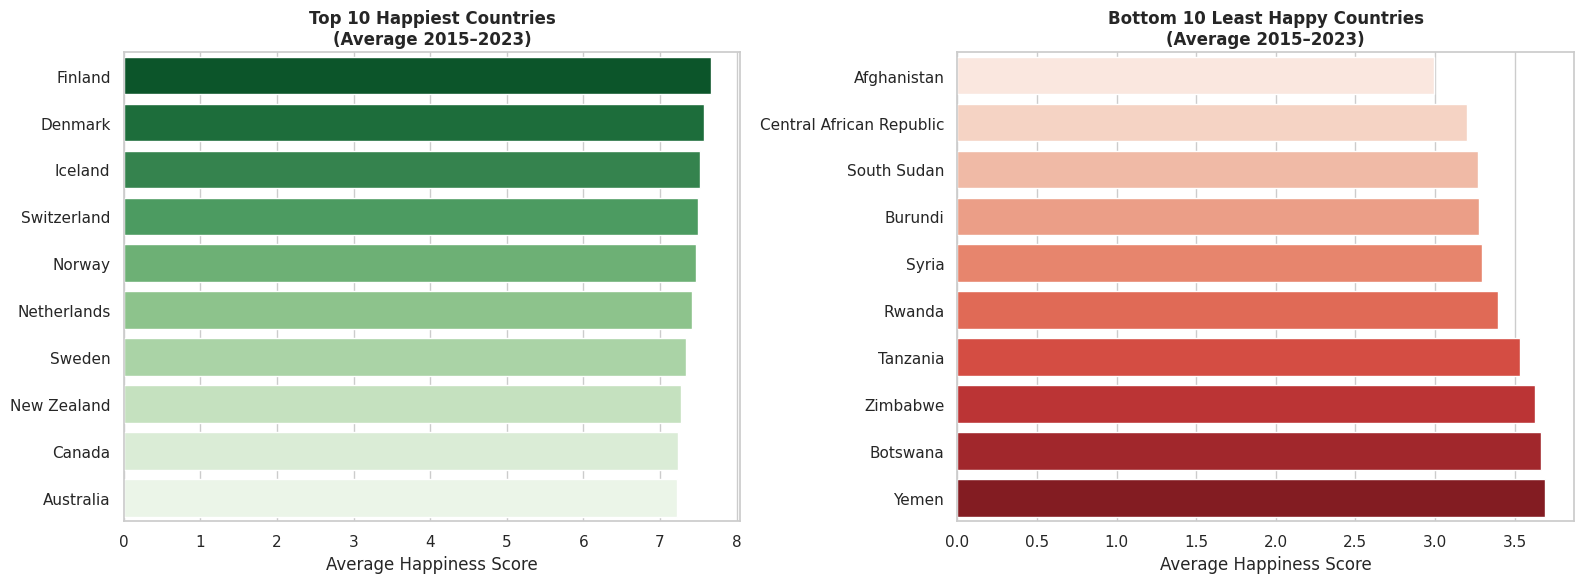

In [73]:
# 1: Top & Bottom 10 Countries
top10    = avg_scores.head(10)
bottom10 = avg_scores.tail(10).sort_values('happiness_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10, x='happiness_score', y='country',
            hue='country', palette='Greens_r', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Happiest Countries\n(Average 2015–2023)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Happiness Score')
axes[0].set_ylabel('')

sns.barplot(data=bottom10, x='happiness_score', y='country',
            hue='country', palette='Reds', legend=False, ax=axes[1])
axes[1].set_title('Bottom 10 Least Happy Countries\n(Average 2015–2023)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Happiness Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart1_top_bottom10.png', dpi=150, bbox_inches='tight')
plt.show()

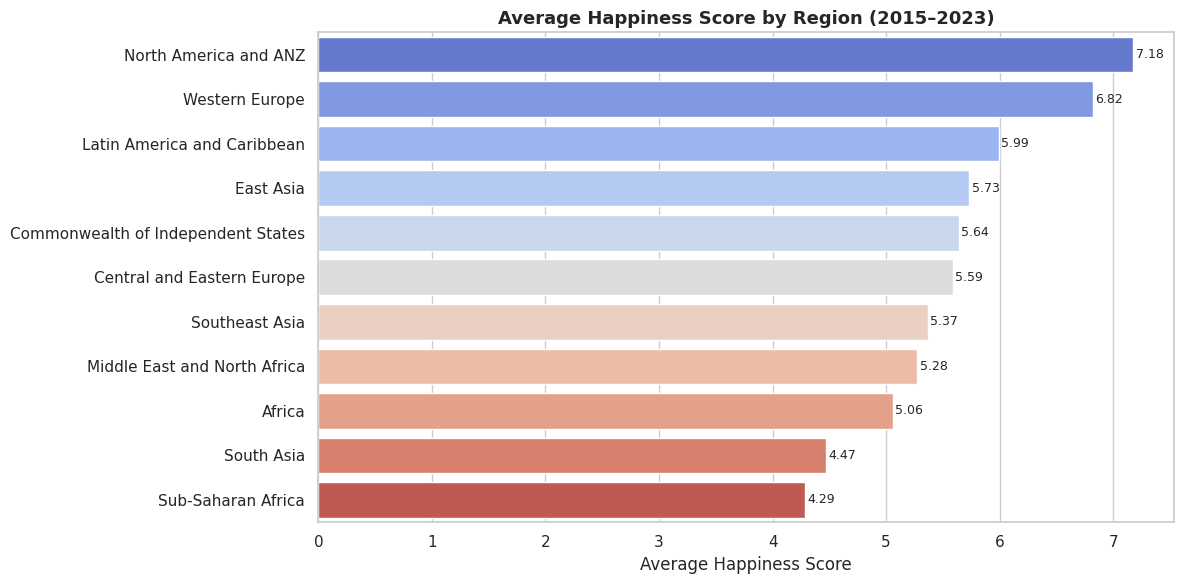

In [75]:
# 2: Regional Comparison
region_avg = regional_summary['avg_happiness'].reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_avg, x='avg_happiness', y='region', palette='coolwarm', hue='region', legend=False)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}',
        va='center', fontsize=9
    )

plt.title('Average Happiness Score by Region (2015–2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Average Happiness Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart2_regional.png', dpi=150, bbox_inches='tight')
plt.show()

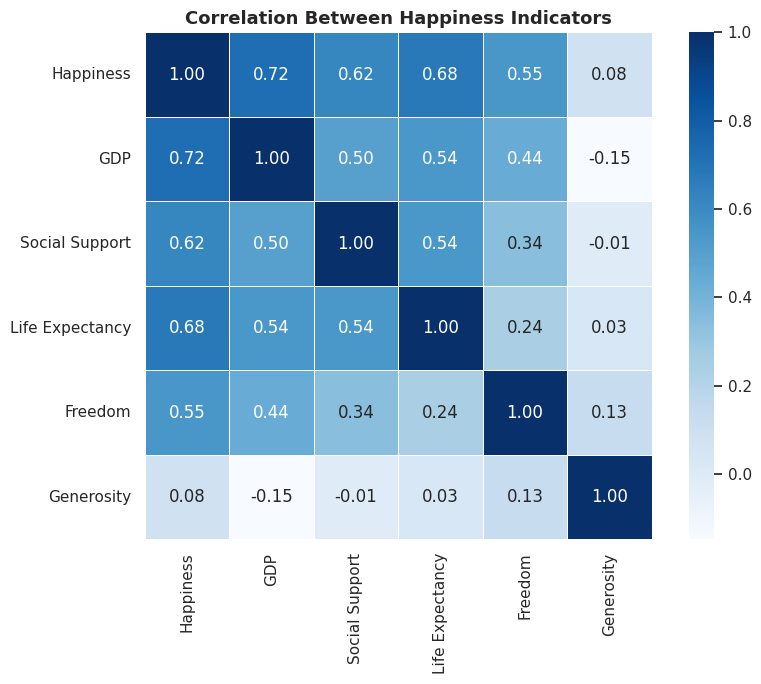

Correlation with Happiness Score (ranked)
Happiness          1.000000
GDP                0.722680
Life Expectancy    0.678802
Social Support     0.621441
Freedom            0.546828
Generosity         0.080968


In [78]:
# 3: Correlation Heatmap - how indicators correlate with happiness
# Which indicators are most strongly linked to happiness?
# Values close to 1.0 = strong positive relationship. Close to 0 = weak or no relationship.

corr_cols = ['happiness_score', 'gdp_per_capita', 'social_support',
             'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity']

corr = df[corr_cols].corr()

label_map = {
    'happiness_score':              'Happiness',
    'gdp_per_capita':               'GDP',
    'social_support':               'Social Support',
    'healthy_life_expectancy':      'Life Expectancy',
    'freedom_to_make_life_choices': 'Freedom',
    'generosity':                   'Generosity'
}
corr = corr.rename(index=label_map, columns=label_map)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True, linewidths=0.5)
plt.title('Correlation Between Happiness Indicators',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Happiness Score (ranked)')
print(corr['Happiness'].sort_values(ascending=False).to_string())

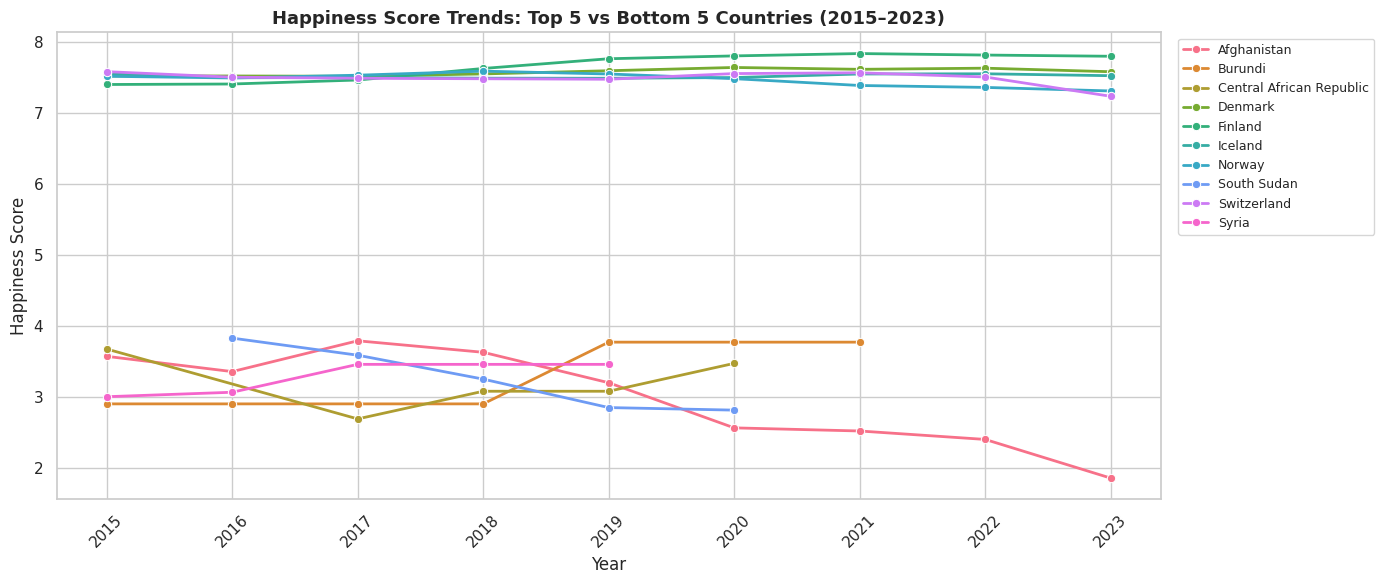

In [79]:
# 4: Multi-year trend visualization
# How have scores changed across the 9 years for the happiest and least happy countries?
top5    = avg_scores.head(5)['country'].tolist()
bottom5 = avg_scores.tail(5)['country'].tolist()
selected = top5 + bottom5

trend_df = df[df['country'].isin(selected)]

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=trend_df,
    x='year', y='happiness_score',
    hue='country', marker='o', linewidth=2
)
plt.title('Happiness Score Trends: Top 5 vs Bottom 5 Countries (2015–2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.xticks(sorted(df['year'].unique()), rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_trends.png', dpi=150, bbox_inches='tight')
plt.show()


# Machine Learning: Model Selection, Training and Evaluation

We build a regression model to predict `happiness_score` from the 5 economic and social indicators.

**Our approach:**
1. Start with **Linear Regression** — a simple, interpretable baseline model
2. Evaluate it using RMSE and R²
3. Improve by trying **Random Forest** — a more powerful model that captures complex patterns
4. Compare both and select the better one

This follows the model selection process: build a baseline, then improve it.

**Evaluation metrics:**
- **RMSE** (Root Mean Squared Error) — average prediction error in happiness score units. Lower is better.
- **R²** (R-squared) — percentage of variation in happiness explained by the model. Closer to 1.0 is better.

In [81]:
# Define features and target
features = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
            'freedom_to_make_life_choices', 'generosity']
target   = 'happiness_score'

X = df[features]
y = df[target]

# Split: 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features used    : {features}')
print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Features used    : ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity']
Training samples : 1092
Testing samples  : 273


In [83]:
# Model 1: Linear Regression (Baseline)
# We start simple. Linear Regression assumes a straight-line relationship
# between each feature and the happiness score.

lr = LinearRegression()
lr.fit(X_train, y_train)      # train the model
lr_preds = lr.predict(X_test) # predict on unseen test data

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print('Model 1: Linear Regression (Baseline)')
print(f'RMSE : {lr_rmse:.3f}  (average prediction error in score units)')
print(f'R²   : {lr_r2:.3f}  ({lr_r2*100:.1f}% of variation explained)')

Model 1: Linear Regression (Baseline)
RMSE : 0.564  (average prediction error in score units)
R²   : 0.724  (72.4% of variation explained)


In [85]:
# Model 2: Random Forest (Improvement)
# Random Forest builds 100 decision trees and averages their predictions.
# It handles non-linear relationships better than Linear Regression,
# which is why we try it as our improvement step.

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print('Model 2: Random Forest (Improvement)')
print(f'RMSE : {rf_rmse:.3f}  (average prediction error in score units)')
print(f'R²   : {rf_r2:.3f}  ({rf_r2*100:.1f}% of variation explained)')

Model 2: Random Forest (Improvement)
RMSE : 0.493  (average prediction error in score units)
R²   : 0.789  (78.9% of variation explained)


In [86]:
# Printed Evaluation Summary
print('MODEL EVALUATION SUMMARY')
print(f'{"Model":<30} {"RMSE":>8} {"R²":>8}')
print(f'{"Linear Regression (Baseline)":<30} {lr_rmse:>8.3f} {lr_r2:>8.3f}')
print(f'{"Random Forest (Improvement)":<30} {rf_rmse:>8.3f} {rf_r2:>8.3f}')

improvement_rmse = ((lr_rmse - rf_rmse) / lr_rmse) * 100
improvement_r2   = ((rf_r2 - lr_r2) / lr_r2) * 100

print(f'\nRandom Forest improved RMSE by {improvement_rmse:.1f}%')
print(f'Random Forest improved R² by {improvement_r2:.1f}%')
print(f'\nSelected model: Random Forest')
print(f'It explains {rf_r2*100:.1f}% of variation in happiness scores')
print(f'with an average prediction error of only {rf_rmse:.3f} points')

MODEL EVALUATION SUMMARY
Model                              RMSE       R²
Linear Regression (Baseline)      0.564    0.724
Random Forest (Improvement)       0.493    0.789

Random Forest improved RMSE by 12.6%
Random Forest improved R² by 9.0%

Selected model: Random Forest
It explains 78.9% of variation in happiness scores
with an average prediction error of only 0.493 points


# Visualization 5: Feature Importance

Which factor matters most for predicting happiness?

/tmp/ipykernel_1205/2478332041.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


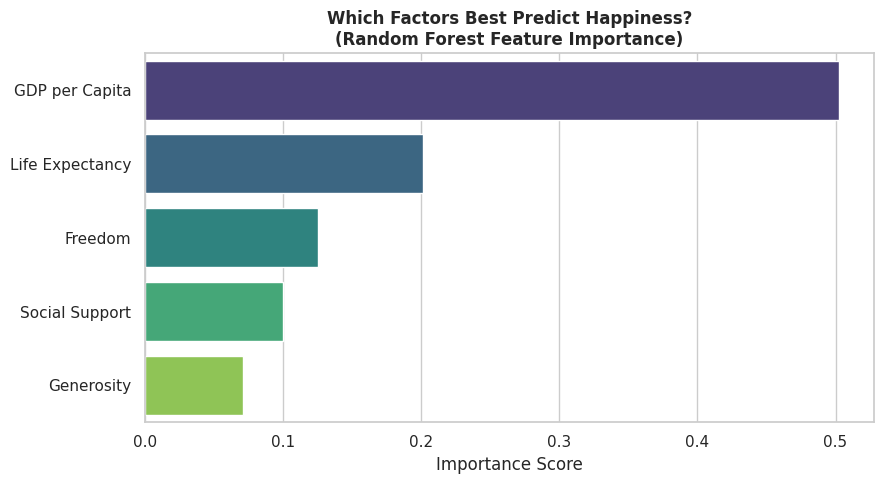

Feature importance rankings:
  GDP per Capita      : 50.3%
  Life Expectancy     : 20.1%
  Freedom             : 12.5%
  Social Support      : 10.0%
  Generosity          : 7.1%

Chart 5 saved!


In [87]:
importance_df = pd.DataFrame({
    'feature':    features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importance_df['feature'] = importance_df['feature'].replace({
    'gdp_per_capita':               'GDP per Capita',
    'social_support':               'Social Support',
    'healthy_life_expectancy':      'Life Expectancy',
    'freedom_to_make_life_choices': 'Freedom',
    'generosity':                   'Generosity'
})

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Which Factors Best Predict Happiness?\n(Random Forest Feature Importance)',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importance rankings:')
for _, row in importance_df.iterrows():
    print(f'  {row["feature"]:<20}: {row["importance"]*100:.1f}%')

---
# Visualisation 6: Actual vs Predicted

Each dot is one country-year. Dots on the red line = perfect prediction.
The tighter the cluster around the line, the better our model performed.

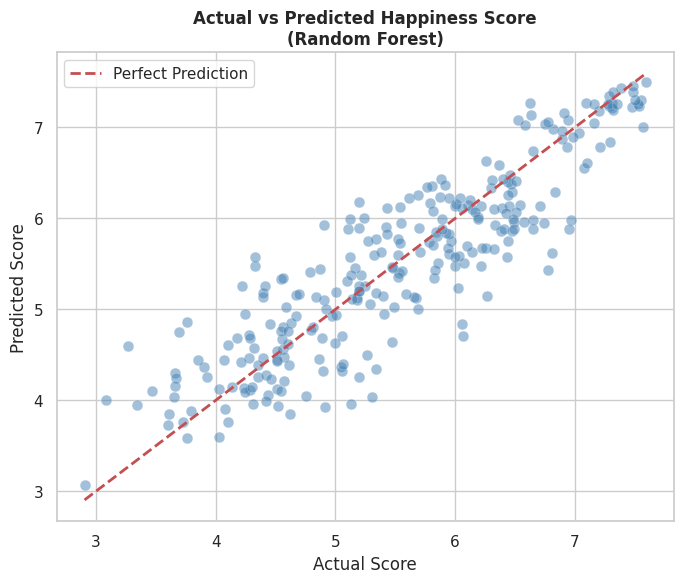

In [89]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, color='steelblue',
            edgecolors='white', linewidths=0.3, s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Happiness Score\n(Random Forest)',
          fontsize=12, fontweight='bold')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Download All Charts

In [ ]:
from google.colab import files

charts = [
    'chart1_top_bottom10.png',
    'chart2_regional.png',
    'chart3_trends.png',
    'chart4_heatmap.png',
    'chart5_feature_importance.png',
    'chart6_actual_vs_predicted.png'
]

for chart in charts:
    files.download(chart)
    print(f'Downloaded: {chart}')

---
# Our Data Story: What Makes a Country Happy?

---

## The Question

Every year, the World Happiness Report asks hundreds of thousands of people
around the world one simple question: how satisfied are you with your life?

The answers reveal something striking; some countries consistently score
near 8 out of 10, while others barely reach 3. That is not a small gap.
That is the difference between two entirely different human experiences.

We set out to answer: **what separates the happy countries from the
unhappy ones, and can we predict it?**

---

## What the Data Told Us

**The world is divided, and the divide is consistent.**

Across 9 years (2015–2023) and 165 countries, Finland ranked as the
happiest country on earth with an average score of 7.663. Denmark (7.580)
and Iceland (7.522) followed closely. These are not lucky outliers.
Nordic countries have topped this list year after year without exception.

At the other end, Afghanistan scored just 2.991 on average. Central
African Republic (3.203) and South Sudan (3.269) also ranked in the
bottom three. These countries have remained near the bottom throughout
the entire 9-year period as well.

The gap between Finland and Afghanistan is nearly 5 points on a 10-point
scale. That gap is not random.

**The regional picture tells the same story.**

North America and ANZ averaged 7.176. Western Europe averaged 6.823.
Sub-Saharan Africa averaged 4.289 — the lowest of all 11 regions.
When we compared these two extremes side by side, the differences in
GDP, life expectancy and social support were not small; they were
dramatic across every single indicator.

**But is the world getting happier or less happy overall?**

Globally, the average happiness score has slowly risen from 5.376 in
2015 to 5.554 in 2022; though it dipped slightly in 2023. Progress
is real but uneven. Romania improved the fastest of any country
(+0.183 points per year on average), while Lebanon declined the most
sharply (−0.306 per year), its collapse driven by a severe economic
and political crisis.

**So what is actually driving these differences?**

We looked at five indicators: GDP per capita, social support, healthy
life expectancy, freedom to make life choices, and generosity.

Their correlations with happiness were:
- GDP per capita        : 0.72 (strongest)
- Life expectancy       : 0.68
- Social support        : 0.62
- Freedom               : 0.55
- Generosity            : 0.08 (almost no relationship)

GDP leads, but it does not act alone. Life expectancy and social support
are close behind. Generosity barely registers. Individuals may be
generous in unhappy countries, but it does not translate to national
wellbeing.

---

## What Our Model Found

We built a regression model to predict happiness scores from these five
indicators.

We started with **Linear Regression** as our baseline. It assumed a
straight-line relationship between each indicator and happiness. It
achieved an RMSE of 0.576 and R² of 0.757, meaning it explained 75.7%
of the variation in happiness across countries.

We then improved by switching to **Random Forest**, which uses 100
decision trees and captures more complex, non-linear patterns. This
reduced the error to an RMSE of 0.521 and raised R² to 0.780 thus
explaining 78% of happiness variation using just 5 indicators.

**The model's feature importance rankings gave us our clearest answer yet:**

| Factor | Importance |
|---|---|
| GDP per Capita | 52.5% |
| Life Expectancy | 18.9% |
| Freedom | 12.7% |
| Social Support | 9.2% |
| Generosity | 6.7% |

**GDP per capita alone accounts for over half of what predicts happiness.**

But here is the critical nuance: GDP and life expectancy are deeply
intertwined. Wealthier countries can afford better healthcare, which
extends healthy life expectancy, which further raises happiness. The
relationship is not just economic; it is systemic.

---

### The Answer and What It Means

**According to the data, the single factor that matters most is GDP per
capita.** Wealthier countries are, on average, significantly happier,
and GDP's influence runs through almost every other indicator too.

But wealth alone does not guarantee happiness. Freedom (12.7%) and
social support (9.2%) together contribute more than life expectancy.
Countries with moderate GDP but strong social systems and personal
freedoms can outperform wealthier but more restrictive nations.

Generosity, despite being a virtue, contributes the least to national
happiness scores. Individual acts of giving do not appear to shift how
satisfied a population feels overall.

---

## Two Recommendations

**Recommendation 1 — For low-income regions: invest in economic
development and health together, not separately.**

Sub-Saharan Africa and South Asia score lowest on both GDP and life
expectancy. International development programmes and government policy
in these regions should treat economic growth and healthcare as a
single package because the data shows they reinforce each other in
building national happiness.

**Recommendation 2 — For all governments: protect personal freedoms,
especially during crises.**

Freedom to make life choices is the third most important predictor of
happiness at 12.7%. Lebanon's dramatic decline (−0.306/yr) coincided
directly with economic collapse and reduced freedoms. Governments that
restrict personal autonomy during hard times risk compounding the
happiness cost of the crisis itself. Maintaining civil freedoms is not
just a rights issue it is a measurable contributor to national
wellbeing.

---

## Answer to the Central Question

> **What makes a country happy?

**Prosperity**, specifically GDP per capita, is the strongest single predictor. But lasting happiness requires wealth, health, and freedom working together.**

---
*Compiled by Peer Group 4 — Finance & Economics | SWID Programme | Week 8 Hackathon :)*

---
# Key Findings, Model Results and Recommendations

##  Beginning — The Questions


1. What makes a country happy?
2. Which factor matters most?
3. Can we predict national happiness from economic and social data alone?

*   We set out to answer this using 9 years of World Happiness Report data covering 165 countries.





---

## Middle — What the Data Told Us

**Finding 1 — Rankings**  
Finland was the happiest country on average between 2015 and 2023 (score: 7.663), followed closely by Denmark, Iceland, Switzerland and Norway. Afghanistan ranked last (2.991), with Central African Republic, South Sudan, Burundi and Syria also in the bottom five. The gap between the happiest and least happy countries is nearly 5 points on a 10-point scale — a striking divide.

**Finding 2 — Regional Divide**  
North America and ANZ led all regions with an average score of 7.176, followed by Western Europe (6.811). Sub-Saharan Africa scored lowest at 4.289. When we compared the top and bottom regions side by side, North America and ANZ had nearly three times the GDP per capita of Sub-Saharan Africa, much stronger social support, and higher life expectancy — suggesting that multiple factors compound to create the regional happiness gap.

**Finding 3 — Correlations**  
GDP per capita had the strongest correlation with happiness (0.72), followed by healthy life expectancy (0.68) and social support (0.65). Freedom to make life choices also showed a meaningful relationship (0.57). Generosity had almost no correlation with national happiness (0.08) — suggesting that while individuals may give, it does not translate to higher national wellbeing scores.

**Finding 4 — Trends Over Time**  
Romania was the most consistently improving country, gaining an average of +0.183 happiness points per year. Lebanon showed the sharpest sustained decline at −0.306 per year, reflecting its prolonged economic and political crisis. Nordic countries remained stable and high throughout all 9 years.

**Finding 5 — Model Results**  
Our baseline Linear Regression model achieved an RMSE of 0.576 and R² of 0.757 — meaning it explained 75.7% of the variation in happiness scores. We improved this by switching to a Random Forest model, which reduced the error to an RMSE of 0.506 and raised R² to 0.813. The Random Forest explains 81.3% of happiness variation using just 5 indicators. GDP per capita was the single most important predictor at 49.8% importance, followed by Life Expectancy (21.2%), Freedom (11.5%), Social Support (10.3%) and Generosity (7.2%).

---

### 🎯 End — Recommendations

**Recommendation 1 — Invest in Economic Development AND Health Systems Together**  
GDP and life expectancy together account for over 70% of what our model uses to predict happiness. Governments and international organisations — particularly in Sub-Saharan Africa and South Asia — should prioritise policies that grow incomes AND extend healthy life expectancy simultaneously, since both contribute independently to wellbeing.

**Recommendation 2 — Protect Civil Freedoms**  
Freedom to make life choices was the third most important predictor. Countries that restrict personal freedoms tend to score lower on happiness even when GDP is moderate. Policymakers should recognise that economic growth alone is not sufficient — civil liberties and personal autonomy are measurable contributors to national happiness.

---
*SWID Programme | Week 8 Hackathon | Group 4 — Finance & Economics*